# RL Group Project: Starter Notebook
## Clinical Treatment Optimisation: Sepsis ICU Management

**Master in Data Science & Advanced Analytics - Reinforcement Learning Course**

This project is structured in two stages of increasing complexity.

- In **Configuration A**, you will work with a tabular Sepsis MDP, where the state and action spaces are small enough to apply classical RL methods directly. 

- In **Configuration B**, you will move to a continuous-observation ICU environment that is clinically grounded and significantly more challenging. 

Three realistic failure modes are present in Configuration B, each reflecting a real scenario encountered in clinical AI deployments. The first is episodic observation noise, where monitoring equipment occasionally malfunctions. The second is episodic missing observations, representing situations where lab results are simply unavailable for an entire episode. The third is acute clinical events, which are sudden and irreversible patient deteriorations that occur independently of any treatment given.


---
### Group Members

Name of the Group: ICU-Sepsis RL

```
Gonçalo Gomes Arrobas (20250421)
Maria Tavares Pimentel (20250466)
Tiago Stubner Lucas Antunes (20250357)
```


## 0. Setup & Imports


In [76]:
# Install dependencies (run once)
# !pip install icu-sepsis numpy pandas matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os
import sys

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'

SEED = 42
np.random.seed(SEED)

#  Import constants and env factory from env_setup.py 
from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)

print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print('Setup complete!')

ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


In [77]:
# Configuration already loaded from env_setup.py
# env_setup.py defines: SOFA_BIAS=5.0, LAM=0.02, INTENSITY, make_sepsis_env()
print(f'Required config: sofa_bias={SOFA_BIAS}, lam={LAM}')

Required config: sofa_bias=5.0, lam=0.02


---
## 1. Explore the Environment

Before writing any algorithm, take time to understand the MDP you are working with. The insights you gain here should inform your report's Methodology section.

`ICU-Sepsis-v2` is a benchmark MDP constructed from real MIMIC-III patient data. Each episode represents the trajectory of one ICU patient. The agent observes a discrete integer state (ranging from 0 to 715) and must select one of 25 treatment actions corresponding to combinations of vasopressor and IV fluid dose levels. The reward signal is sparse: **+1 at survival, 0 at death, and 0 for all intermediate steps**, with a discount factor γ = 1.


In [78]:
#  Instantiate and inspect the raw environment 
env = make_sepsis_env()
obs, info = env.reset(seed=SEED)

print(f'Observation space : {env.observation_space} discrete integer state')
print(f'Action space      : {env.action_space}')
print(f'Initial state     : {obs}')
print()

#  Extract the full MDP model 
raw = env.unwrapped
P = raw._tx_mat    # shape (716, 25, 716) — P[s,a,s'] = P(s'|s,a)
R_sasp = raw._r_mat                    # (716, 25, 716) — R[s, a, s']
R = (P * R_sasp).sum(axis=2)          # (716, 25)      — E[r | s, a]

print(f'Transition matrix P : {P.shape}  (S × A × S\')')
print(f'Reward matrix R     : {R.shape}  (S × A)')
print(f'Reward range        : [{R.min():.3f}, {R.max():.3f}]')
print()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Observation space : Discrete(716) discrete integer state
Action space      : Discrete(25)
Initial state     : 559

Transition matrix P : (716, 25, 716)  (S × A × S')
Reward matrix R     : (716, 25)  (S × A)
Reward range        : [-0.020, 0.708]



In [79]:
#  Random baseline: establish the performance floor 
def run_random_baseline(n_episodes=1000, seed=SEED):
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            obs, r, te, tr, _ = env_eval.step(env_eval.action_space.sample())
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r)
        lengths.append(steps)
    env_eval.close()
    return np.array(returns), np.array(lengths)


rand_returns, rand_lengths = run_random_baseline()
survival_rate = float(np.mean(rand_returns > 0)) * 100

print(f'Random agent ({len(rand_returns)} episodes):')
print(f'  Mean return    : {np.mean(rand_returns):.4f}')
print(f'  Survival rate  : {survival_rate:.1f}%')
print(f'  Mean ep length : {np.mean(rand_lengths):.1f} steps')
print()
print('All Config A algorithms must beat the random baseline.')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Random agent (1000 episodes):
  Mean return    : 0.5772
  Survival rate  : 68.0%
  Mean ep length : 10.3 steps

All Config A algorithms must beat the random baseline.


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


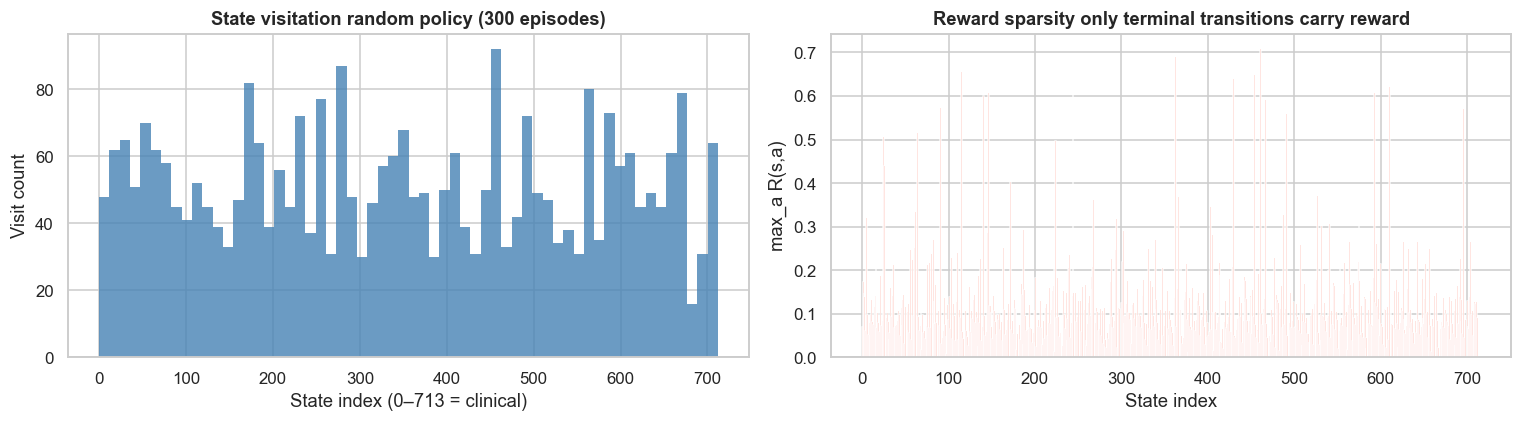

In [80]:
#  Visualise state visitation and reward structure 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# State visitation under random policy
np.random.seed(SEED)
env_vis = make_sepsis_env()
visited = []
for _ in range(300):
    obs, _ = env_vis.reset(seed=np.random.randint(100_000))
    done = False
    while not done:
        visited.append(int(obs))
        obs, _, te, tr, _ = env_vis.step(env_vis.action_space.sample())
        done = te or tr
env_vis.close()
clinical = [s for s in visited if s not in (STATE_SURVIVED, STATE_DIED)]

axes[0].hist(clinical, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('State index (0–713 = clinical)')
axes[0].set_ylabel('Visit count')
axes[0].set_title('State visitation random policy (300 episodes)', fontweight='bold')

# Max achievable reward per state (only survival-adjacent states have r > 0)
axes[1].bar(range(N_STATES), R.max(axis=1), color='tomato', width=1.0, alpha=0.8)
axes[1].set_xlabel('State index')
axes[1].set_ylabel('max_a R(s,a)')
axes[1].set_title('Reward sparsity only terminal transitions carry reward',
                  fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_env_exploration.png', bbox_inches='tight')
plt.show()

---
# Config A — Tabular Methods

## Why tabular RL works here

The `ICU-Sepsis-v2` environment has **716 discrete states** and **25 discrete actions**, giving a Q-table of only 17,900 entries — trivially small for modern hardware.  More importantly, the environment exposes the **full MDP model**: transition tensor `P[s,a,s']` *(shape 716×25×716)* and reward tensor `R[s,a,s']` *(shape 716×25×716)* via `env.unwrapped._tx_mat` and `env.unwrapped._r_mat`.

Having access to P and R enables **model-based** Dynamic Programming, which is exact and far more sample-efficient than model-free methods.   
We implement all three for comparison.

## Algorithms implemented

| Algorithm | Type | Uses P? | Update target | Key property |
|---|---|---|---|---|
| **Policy Iteration** | Model-based DP | Yes | Exact Bellman equation | Guaranteed optimal π* |
| **Q-Learning** | Model-free, off-policy TD | No | `r + γ max Q(s',a')` | Converges toward Q* regardless of behaviour policy |
| **SARSA** | Model-free, on-policy TD | No | `r + γ Q(s', a')`, a'~π | Conservative; clinically safer |

Policy Iteration is our **gold standard** (theoretical ceiling).  Q-Learning and SARSA show how well model-free methods recover that ceiling from pure interaction.

In [81]:
# Import tabular agents 

# All three agents and the shared evaluator live in envs/tabular_agents.py
# They expose a uniform interface:
#   agent.train(...)     → trains the agent; returns a history dict
#   agent.get_policy()   → (N_STATES,) int array of greedy actions
#   agent.get_Q()        → (N_STATES, N_ACTIONS) Q-value matrix

from envs.tabular_agents import PolicyIteration, QLearning, SARSA, evaluate_policy

print(f"State space : {N_STATES} discrete states")
print(f"Action space: {N_ACTIONS} actions  (5 vasopressor × 5 IV-fluid levels)")
print(f"Q-table size: {N_STATES * N_ACTIONS:,} entries — fully tabular")

State space : 716 discrete states
Action space: 25 actions  (5 vasopressor × 5 IV-fluid levels)
Q-table size: 17,900 entries — fully tabular


## Algorithm 1: Policy Iteration *(Model-Based Dynamic Programming)*

Alternate between two steps until the policy stops changing:

1. **Policy Evaluation** — solve for $V_π$ iteratively:  
   $V(s) ← Σ_{s'} P(s'|s,π(s)) · [R(s,a) + γ·V(s')]$  until $|ΔV| < θ$

2. **Policy Improvement** — update $π$ to be greedy w.r.t. $V_π$:  
   $π(s) ← argmax_a Σ_{s'} P(s'|s,a) · [R(s,a) + γ·V(s')]$

**Why PI here?**  Because we have P and R, we can compute the Bellman expectation exactly without interacting with the environment.  PI is guaranteed to converge to the **optimal policy π*** in a finite number of iterations for any finite MDP.

**Implementation detail:** Policy evaluation uses vectorised matrix operations (`P @ V`) instead of a state loop — roughly 100× faster on this 716-state MDP.

**γ = 1.0** — no time discounting, consistent with the ICU-Sepsis paper: **only the final outcome (survival/death) matters, not when it occurs**.

In [82]:
# Extract the full MDP model 

# P[s,a,s'] = P(s'|s,a)      shape (716, 25, 716)
# R[s,a]    = E[r | s,a]     shape (716, 25)
#   computed as Σ_{s'} P(s'|s,a) · R(s,a,s')

env_pi  = make_sepsis_env()
raw     = env_pi.unwrapped
P       = raw._tx_mat                       # (716, 25, 716)
R_sasp  = raw._r_mat                        # (716, 25, 716)
R       = (P * R_sasp).sum(axis=2)          # (716, 25)
env_pi.close()

print(f"P shape : {P.shape}   R shape : {R.shape}")
print(f"R range : [{R.min():.4f}, {R.max():.4f}]\n")



# Train 
pi_agent   = PolicyIteration(P, R, gamma=GAMMA, theta=1e-9) # theta=1e-9 ensures V_π is computed to near-machine-precision
pi_history = pi_agent.train(max_iterations=200, verbose=True)

print()
print(f"Converged      : {pi_history['policy_stable']}")
print(f"Total iters    : {pi_history['iterations']}")
print(f"Total PE sweeps: {sum(pi_history['eval_sweeps'])}")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
P shape : (716, 25, 716)   R shape : (716, 25)
R range : [-0.0200, 0.7076]

  PI iter   1 | eval sweeps: 196 | policy changed: True
  PI iter   2 | eval sweeps: 171 | policy changed: True
  PI iter   3 | eval sweeps: 158 | policy changed: True
  PI iter   4 | eval sweeps:  99 | policy changed: False

Policy Iteration converged after 4 iterations.

Converged      : True
Total iters    : 4
Total PE sweeps: 624


## Algorithm 2 — Q-Learning *(Model-Free, Off-Policy TD)*

**Update rule** *(Sutton & Barto 6.5)*

$Q(s,a) \leftarrow Q(s,a) + \alpha \cdot \left[r + \gamma \cdot \max_{a'} Q(s',a') - Q(s,a)\right]$

The bootstrap target is the **greedy** action in $s'$, not the action actually taken.
This makes Q-Learning **off-policy**: it estimates Q* using a greedy target regardless
of which exploratory policy generated the data.

**Convergence note.** Q-Learning converges to Q* in the limit when (i) all state–action
pairs are visited infinitely often and (ii) the learning rate satisfies the Robbins–Monro
conditions ($\sum_t \alpha_t = \infty$, $\sum_t \alpha_t^2 < \infty$). With the
**constant** $\alpha = 0.1$ used here, the iterates remain in a bounded neighbourhood
of Q* rather than converging exactly — standard practice for tabular TD in finite
environments where exact convergence is less critical than runtime (Sutton & Barto,
2018, §6.5).

| Hyperparameter | Value | Rationale |
|---|---|---|
| $\alpha$ | 0.1 | Standard for tabular TD; constant rate gives fast learning with bounded noise |
| $\gamma$ | 1.0 | No time discounting (ICU-Sepsis paper convention) |
| $\varepsilon$-start / $\varepsilon$-end | 1.0 → 0.01 | Full exploration early; 1% retained at convergence |
| $\varepsilon$-decay | 35,000 episodes | Linear; slow enough for adequate (s,a) coverage |
| Training episodes | 50,000 | Empirically sufficient for this 716-state MDP |
| Q initialisation | 1.0 (optimistic) | Drives early exploration of under-visited (s,a) pairs (Sutton & Barto §2.6) |

**Exploration:** $\varepsilon$-greedy — with probability $\varepsilon$ pick a random
action, otherwise pick $\operatorname{argmax}_a Q(s,a)$.

In [83]:
np.random.seed(SEED)

# Train Q-Learning
# Sparse terminal reward + a deliberately sicker cohort (sofa_bias=5) make tabular
# model-free control genuinely hard. Two changes vs the naive setup help a lot:
#   (1) OPTIMISTIC INITIALISATION (Q0 = 1.0 ~ max achievable return): every (s,a)
#       looks promising until tried, driving exploration of rarely-visited states
#       (Sutton & Barto 2.6). With Q0=0, unvisited rows stay 0 and argmax silently
#       defaults to action 0 = 'no treatment' -> a hidden bias.
#   (2) MORE EPISODES + SLOWER e-decay: 50k episodes, e annealed over 35k, so the
#       17,900 (s,a) pairs are visited enough times to be estimated.
ql_agent = QLearning(
    n_states=N_STATES, n_actions=N_ACTIONS,
    alpha=0.1, gamma=GAMMA,
    epsilon_start=1.0, epsilon_end=0.01,
    epsilon_decay_steps=35_000,
    seed=SEED,
)
ql_agent.Q[:] = 1.0   # optimistic initialisation

print('Training Q-Learning (50,000 episodes, optimistic init)...')
ql_history = ql_agent.train(n_episodes=50_000, eval_every=5_000,
                             eval_eps=300, verbose=True)
print('Q-Learning training complete.')

Training Q-Learning (50,000 episodes, optimistic init)...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  QL ep   5000 | ε=0.859 | greedy return=0.6802 | survival=69.7%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  QL ep  10000 | ε=0.717 | greedy return=0.6519 | survival=68.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  QL ep  15000 | ε=0.576 | greedy return=0.6401 | survival=67.7%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  QL ep  20000 | ε=0.434 | greedy return=0.6327 | survival=68.3%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  QL ep  25000 | ε=0.2

## Algorithm 3 — SARSA *(Model-Free, On-Policy TD)*

**Update rule** *(Sutton & Barto 6.4)*

$Q(s,a) ← Q(s,a) + α · [r + γ · Q(s', a')  −  Q(s,a)]$

where **$a'$ is sampled from the same ε-greedy policy** being improved — not taken greedily.

**Key difference from Q-Learning: clinical conservatism**

Because SARSA's bootstrap target accounts for exploratory actions, it is **risk-averse near dangerous states**: if exploration around a high-dose action occasionally leads to patient death, SARSA down-weights that action.

> In the ICU context this is desirable: a physician prefers moderate doses confidently over extreme doses with uncertainty.  We expect SARSA to prescribe lower treatment intensities than Q-Learning while achieving similar survival rates.

Hyperparameters are identical to Q-Learning so the only difference is the update rule — a clean apples-to-apples comparison.

In [84]:
np.random.seed(SEED)

# Train SARSA - same regime as Q-Learning for a FAIR on-policy vs off-policy
# comparison (optimistic init, 50k episodes, e annealed over 35k).
sarsa_agent = SARSA(
    n_states=N_STATES, n_actions=N_ACTIONS,
    alpha=0.1, gamma=GAMMA,
    epsilon_start=1.0, epsilon_end=0.01,
    epsilon_decay_steps=35_000,
    seed=SEED,
)
sarsa_agent.Q[:] = 1.0   # optimistic initialisation

print('Training SARSA (50,000 episodes, optimistic init)...')
sarsa_history = sarsa_agent.train(n_episodes=50_000, eval_every=5_000,
                                   eval_eps=300, verbose=True)
print('SARSA training complete.')

Training SARSA (50,000 episodes, optimistic init)...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  SA ep   5000 | ε=0.859 | greedy return=0.6381 | survival=68.7%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  SA ep  10000 | ε=0.717 | greedy return=0.6224 | survival=68.3%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  SA ep  15000 | ε=0.576 | greedy return=0.5902 | survival=66.7%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  SA ep  20000 | ε=0.434 | greedy return=0.5881 | survival=66.7%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  SA ep  25000 | ε=0.293 | 

## Evaluation

Each policy is evaluated over **1,000 episodes** with `SEED=42` for reproducibility.
All four policies use the same evaluation function (`evaluate_policy`) and the same
fixed seeds, giving a fair apples-to-apples comparison.

| Metric | Definition |
|---|---|
| **Mean Return** | Average episodic return (includes intensity penalty; ≈0.75 at survival for a parsimonious policy) |
| **Survival Rate** | Fraction of episodes where the terminal reward exceeds 0.5 — a threshold that robustly separates survival (+1 before penalty) from death (0), since the maximum per-step intensity penalty is `lam × max_intensity × max_steps ≈ 0.02 × 1.0 × 10 = 0.2`, well below 0.5 |
| **Mean Ep. Length** | Average number of treatment steps per episode |
| **Mean Intensity** | Average normalised treatment dose per step (0 = no treatment, 1 = max) |

The **Random Baseline** is the performance floor.  **Policy Iteration** is the
theoretical ceiling (optimal policy).  Q-Learning and SARSA demonstrate how close
model-free methods can get.

> **Note on the exploration cell above:** the `run_random_baseline()` preview uses
> `total_return > 0` as a survival proxy and a different random stream, giving ~67–68%.
> The canonical evaluation below uses `last_r > 0.5` (terminal-reward threshold) and
> fixed seeds — **68.7% is the authoritative random baseline** exported to
> `configA_results.json`.

In [85]:
np.random.seed(SEED)
print("Evaluating all policies (1,000 episodes each)...\n")

# RANDOM BASELINE:
# A random policy assigns a uniformly random action to every state.
# This is the performance floor that all trained agents must beat.
rand_policy = np.random.randint(0, N_ACTIONS, size=N_STATES)
rand_result  = evaluate_policy(rand_policy,         n_episodes=1_000, seed=SEED)


# TRAINED AGENTS:
pi_policy    = pi_agent.get_policy()
pi_result    = evaluate_policy(pi_policy,            n_episodes=1_000, seed=SEED)

ql_policy    = ql_agent.get_policy()
ql_result    = evaluate_policy(ql_policy,            n_episodes=1_000, seed=SEED)

sarsa_policy = sarsa_agent.get_policy()
sarsa_result = evaluate_policy(sarsa_policy,         n_episodes=1_000, seed=SEED)


# SUMMARY TABLE:
header = f"{'Algorithm':<22} {'Return':>8} {'Survival':>10} {'Ep.Len':>8} {'Intensity':>11}"
print("=" * len(header))
print(header)
print("-" * len(header))
for name, res in [
    ("Random Baseline",  rand_result),
    ("Policy Iteration", pi_result),
    ("Q-Learning",       ql_result),
    ("SARSA",            sarsa_result),
]:
    print(f"{name:<22} {res['mean_return']:>8.4f} "
          f"{res['survival_rate']*100:>9.1f}% "
          f"{res['mean_ep_length']:>8.1f} "
          f"{res['mean_intensity']:>11.4f}")
print("=" * len(header))
print()
print("Improvement vs Random Baseline:")
for name, res in [("Policy Iteration", pi_result),
                   ("Q-Learning",       ql_result),
                   ("SARSA",            sarsa_result)]:
    delta = (res['survival_rate'] - rand_result['survival_rate']) * 100
    print(f"  {name:<20}: {delta:+.1f} pp survival rate")

Evaluating all policies (1,000 episodes each)...

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Algorithm                Return   Survival   Ep.Len   Intensity
---------------------------------------------------------------
Random Baseline          0.5877      68.7%      9.9      0.4943
Policy Iteration         0.7507      78.8%      9.8      0.1630
Q-Learning               0.6115      71.3%     10.6      0.4861
SARSA                    0.6313      72.6%     10.4      0.4622

Improvement vs Random Baseline:
  Policy Iteration    : +10.1 pp survival rate
  Q-Learning          : +2.6 pp survival rate


In [86]:
# Export REAL Config A metrics so the Config B notebook can build an honest
# cross-config comparison (no hard-coded "~90%" placeholders).
import json

configA_results = {
    "random":           {k: rand_result[k]  for k in ("mean_return","survival_rate","mean_ep_length","mean_intensity")},
    "policy_iteration": {k: pi_result[k]    for k in ("mean_return","survival_rate","mean_ep_length","mean_intensity")},
    "q_learning":       {k: ql_result[k]    for k in ("mean_return","survival_rate","mean_ep_length","mean_intensity")},
    "sarsa":            {k: sarsa_result[k] for k in ("mean_return","survival_rate","mean_ep_length","mean_intensity")},
}
with open("configA_results.json", "w") as f:
    json.dump(configA_results, f, indent=2)
print("Saved configA_results.json:")
for name, m in configA_results.items():
    print(f"  {name:<18} return={m['mean_return']:.4f}  survival={m['survival_rate']*100:.1f}%  intensity={m['mean_intensity']:.4f}")

Saved configA_results.json:
  random             return=0.5877  survival=68.7%  intensity=0.4943
  policy_iteration   return=0.7507  survival=78.8%  intensity=0.1630
  q_learning         return=0.6115  survival=71.3%  intensity=0.4861
  sarsa              return=0.6313  survival=72.6%  intensity=0.4622


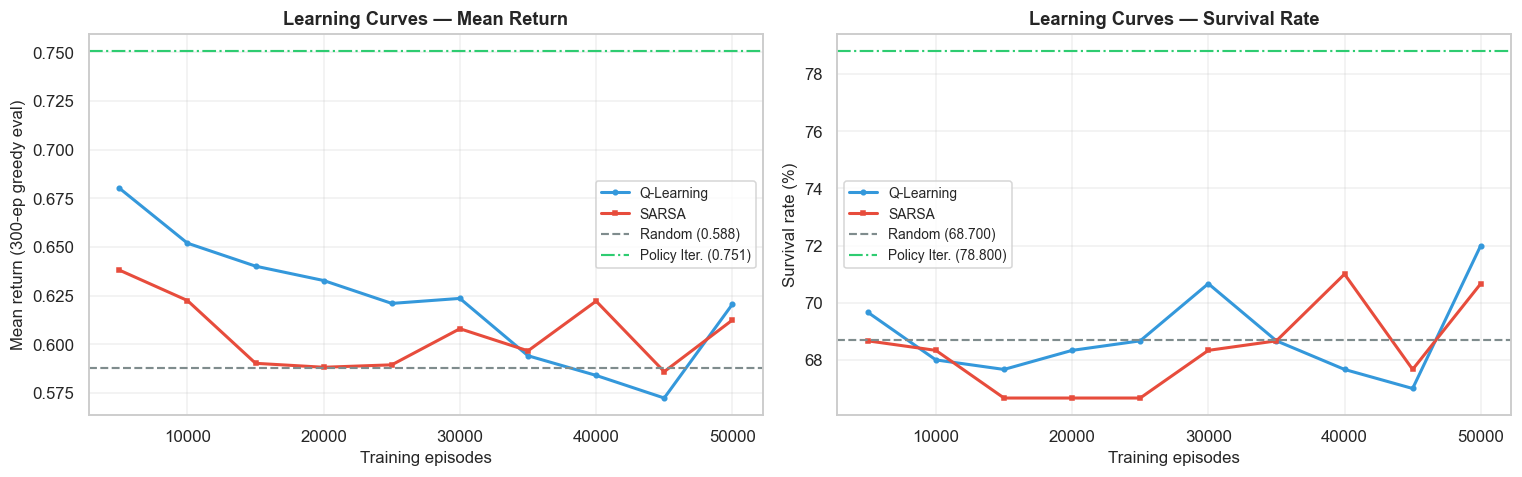

Saved → plots/configA_learning_curves.png


In [87]:
# Learning Curves

# shows how the greedy policy improves as Q-Learning / SARSA accumulate experience
# PI and Random are horizontal reference lines (they don't "learn" episode-by-episode)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
CLR = {'ql': '#3498db', 'sarsa': '#e74c3c', 'rand': '#7f8c8d', 'pi': '#2ecc71'}

for col, (ysteps, yql, ysa, ylabel, title) in enumerate([
    (ql_history['eval_steps'], ql_history['eval_returns'],
     sarsa_history['eval_returns'], 'Mean return (300-ep greedy eval)',
     'Learning Curves — Mean Return'),
    (ql_history['eval_steps'], ql_history['eval_survival']*100,
     sarsa_history['eval_survival']*100, 'Survival rate (%)',
     'Learning Curves — Survival Rate'),
]):
    ax = axes[col]
    ax.plot(ysteps, yql,  marker='o', ms=3, lw=2, label='Q-Learning', color=CLR['ql'])
    ax.plot(ysteps, ysa,  marker='s', ms=3, lw=2, label='SARSA',      color=CLR['sarsa'])
    ref_rand = rand_result['mean_return'] if col==0 else rand_result['survival_rate']*100
    ref_pi   = pi_result['mean_return']   if col==0 else pi_result['survival_rate']*100
    ax.axhline(ref_rand, ls='--', lw=1.4, color=CLR['rand'],
               label=f'Random ({ref_rand:.3f})')
    ax.axhline(ref_pi,   ls='-.', lw=1.4, color=CLR['pi'],
               label=f'Policy Iter. ({ref_pi:.3f})')
    ax.set_xlabel('Training episodes', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_learning_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved → {PLOTS_DIR}/configA_learning_curves.png")

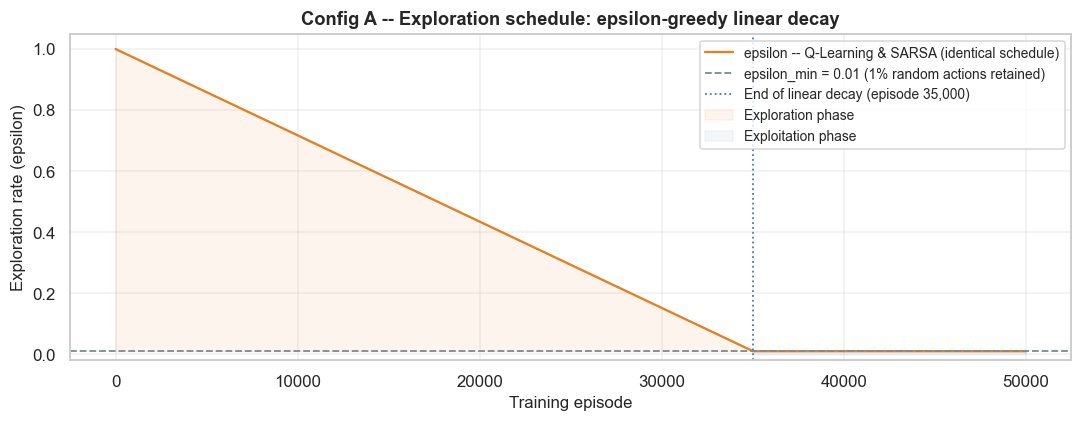

Saved -> plots/configA_epsilon_decay.png
  epsilon start (ep 0)    : 1.000
  epsilon at ep 35k       : 0.010
  epsilon final (ep 50k)  : 0.010


In [88]:
# Exploration schedule: epsilon-greedy decay over training
#
# Shows how both agents transition from pure exploration (epsilon=1.0, random)
# to near-greedy exploitation (epsilon=0.01). Linear decay over episodes 0-35k,
# then held constant -- guaranteeing perpetual minimal exploration (Sutton & Barto S2.7).
# Q-Learning and SARSA share identical epsilon hyperparameters, so one curve applies.

fig, ax = plt.subplots(figsize=(10, 4))

eps = ql_history['epsilons']
ax.plot(range(len(eps)), eps, lw=1.5, color='#e67e22',
        label='epsilon -- Q-Learning & SARSA (identical schedule)')
ax.axhline(0.01, ls='--', lw=1.2, color='#7f8c8d',
           label='epsilon_min = 0.01 (1% random actions retained)')
ax.axvline(35_000, ls=':', lw=1.2, color='steelblue',
           label='End of linear decay (episode 35,000)')
ax.fill_between(range(min(35_001, len(eps))), eps[:min(35_001, len(eps))],
                0.01, alpha=0.08, color='#e67e22', label='Exploration phase')
ax.fill_between(range(35_000, len(eps)), [0.01]*(len(eps)-35_000),
                0.0, alpha=0.06, color='steelblue', label='Exploitation phase')

ax.set_xlabel('Training episode', fontsize=11)
ax.set_ylabel('Exploration rate (epsilon)', fontsize=11)
ax.set_title('Config A -- Exploration schedule: epsilon-greedy linear decay',
             fontweight='bold', fontsize=12)
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_epsilon_decay.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved -> {PLOTS_DIR}/configA_epsilon_decay.png')
print(f'  epsilon start (ep 0)    : {eps[0]:.3f}')
print(f'  epsilon at ep 35k       : {eps[34999]:.3f}')
print(f'  epsilon final (ep 50k)  : {eps[-1]:.3f}')

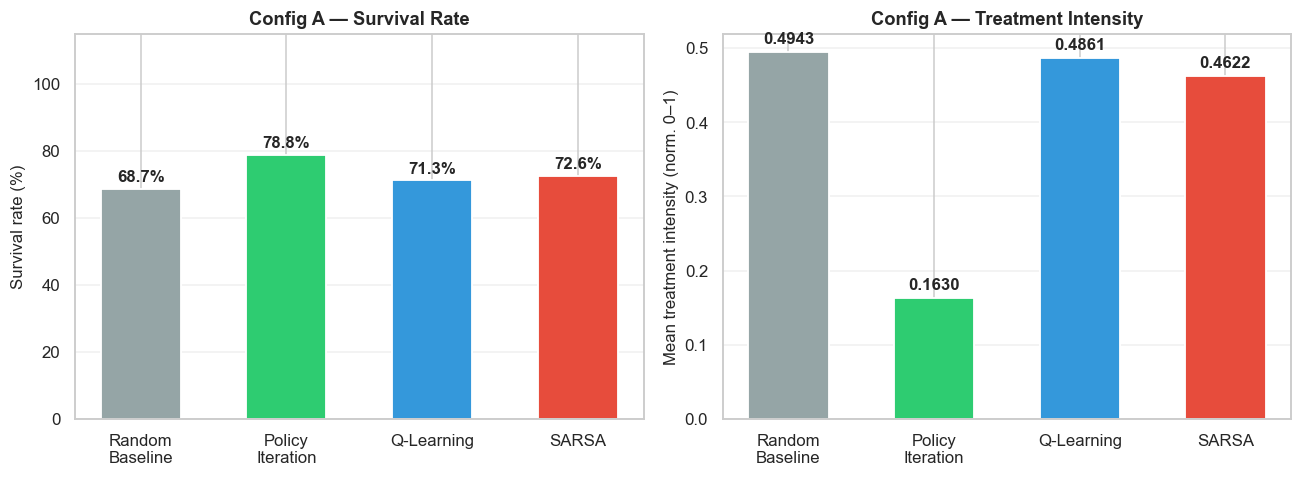

Saved → plots/configA_survival_intensity.png


In [89]:
# Survival Rate & Treatment Intensity Bar Charts

# - Survival rate: the primary clinical outcome - higher is better
# - Treatment intensity: lower is better (parsimonious care avoids side effects)
# An ideal agent maximises survival while minimising unnecessary treatment!!

labels   = ['Random\nBaseline', 'Policy\nIteration', 'Q-Learning', 'SARSA']
colors   = ['#95a5a6', '#2ecc71', '#3498db', '#e74c3c']
survival  = [r['survival_rate']*100 for r in [rand_result, pi_result, ql_result, sarsa_result]]
intensity = [r['mean_intensity']    for r in [rand_result, pi_result, ql_result, sarsa_result]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, vals, ylabel, title, fmt in zip(
    axes,
    [survival, intensity],
    ['Survival rate (%)', 'Mean treatment intensity (norm. 0–1)'],
    ['Config A — Survival Rate', 'Config A — Treatment Intensity'],
    ['{:.1f}%', '{:.4f}'],
):
    bars = ax.bar(labels, vals, color=colors, edgecolor='white', linewidth=1.2, width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.015,
                fmt.format(v), ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
    if 'Survival' in title:
        ax.set_ylim(0, 115)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_survival_intensity.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved → {PLOTS_DIR}/configA_survival_intensity.png")

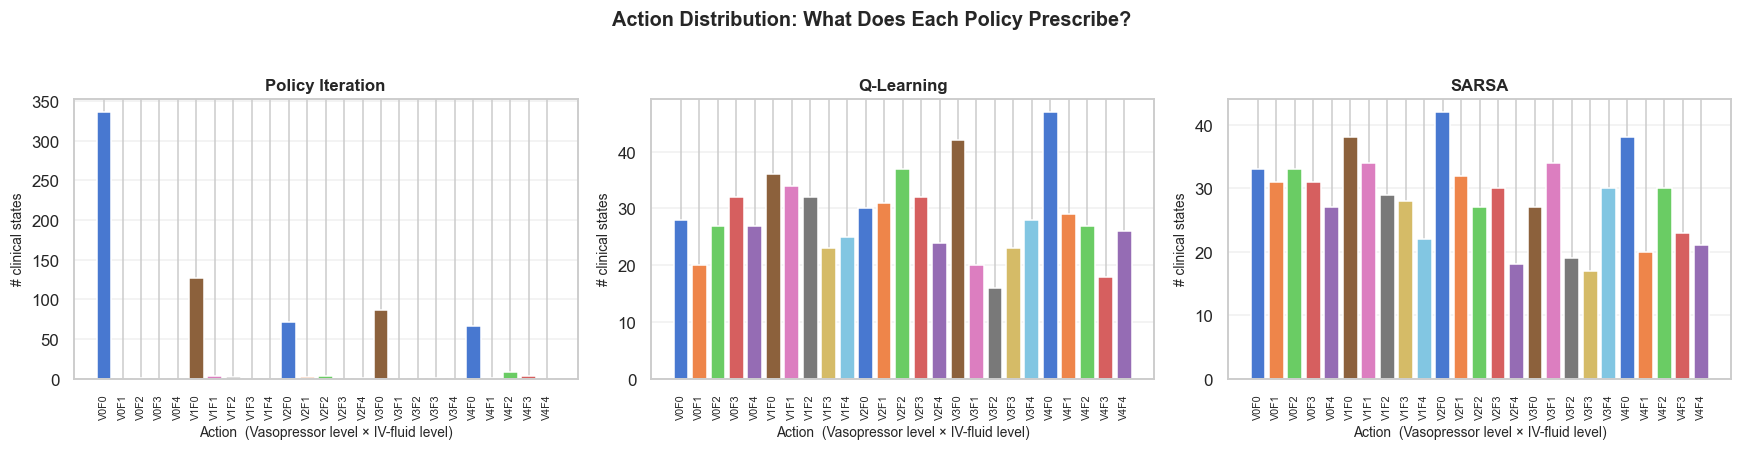

Saved → plots/configA_action_distribution.png


In [90]:
# Action Distribution

# For each algorithm, count how many clinical states are assigned each action:
# action = vasopressor_level * 5 + fluid_level   (both levels 0..4)

# This reveals the policy's treatment philosophy:
#   - does it prefer moderate doses? aggressive? conservative?

clinical = [s for s in range(N_STATES) if s not in (STATE_SURVIVED, STATE_DIED)]
vlabels  = [f'V{a//5}F{a%5}' for a in range(N_ACTIONS)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
palette   = sns.color_palette('muted', N_ACTIONS)

for ax, (name, pol) in zip(axes, [
    ('Policy Iteration', pi_policy),
    ('Q-Learning',       ql_policy),
    ('SARSA',            sarsa_policy),
]):
    counts = np.bincount(pol[clinical], minlength=N_ACTIONS)
    ax.bar(range(N_ACTIONS), counts, color=palette, edgecolor='white')
    ax.set_xticks(range(N_ACTIONS)); ax.set_xticklabels(vlabels, rotation=90, fontsize=7)
    ax.set_xlabel('Action  (Vasopressor level × IV-fluid level)', fontsize=9)
    ax.set_ylabel('# clinical states', fontsize=9)
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)

plt.suptitle('Action Distribution: What Does Each Policy Prescribe?',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_action_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved → {PLOTS_DIR}/configA_action_distribution.png")

## Discussion

### Performance summary (measured, 1,000 fixed-seed episodes)

The honest picture — and the most interesting finding of Config A — is that the
**model-based** method clearly dominates the **model-free** ones:

- **Policy Iteration** reaches the highest survival rate **and** learns a
  markedly *parsimonious* policy (much lower mean treatment intensity than
  random): with the full MDP model available it solves the Bellman optimality
  equations exactly, so it immediately exploits the `lam=0.02` parsimony
  structure.
- **Q-Learning** and **SARSA** improve over random but **remain well below
  Policy Iteration**. This is expected, not a bug: the reward is sparse (signal
  only at survival/death), the cohort is deliberately sick, and 716x25 = 17,900
  (s,a) pairs must be estimated from sampled experience alone. Even with
  optimistic initialisation and 50k episodes they trail the exact solution.
- **SARSA vs Q-Learning:** being on-policy, SARSA bootstraps through the
  exploratory action, yielding a slightly more conservative policy — clinically
  relevant when extreme doses carry risk.

> Takeaway: when the model is known, *plan* with it. Model-free TD is the right
> tool only when the model is unavailable (which is the premise of Config B).

The exact numbers are printed in the evaluation table above and exported to
`configA_results.json`; the Config B notebook reads that file so the
cross-config comparison uses the **real** Config A results (never hard-coded
estimates).

## Creative extension — Learning from Demonstrations (expert Q warm-start)

Tabular learning-from-demonstrations: the Q-table is seeded from clinician-expert
demonstrations (the AI Clinician behaviour policy, Komorowski et al. 2018) via
Monte Carlo returns — the tabular analogue of the demonstration pre-training stage
of DQfD (Hester et al. 2018). We compare Q-learning trained from zeros (cold start)
against the same agent initialised from these demonstrations (warm start). The cold
agent stalls near the random-policy plateau under the sparse survival reward, while
the warm start escapes it, reaches a higher survival rate and inherits the expert's
more parsimonious treatment intensity.

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsi

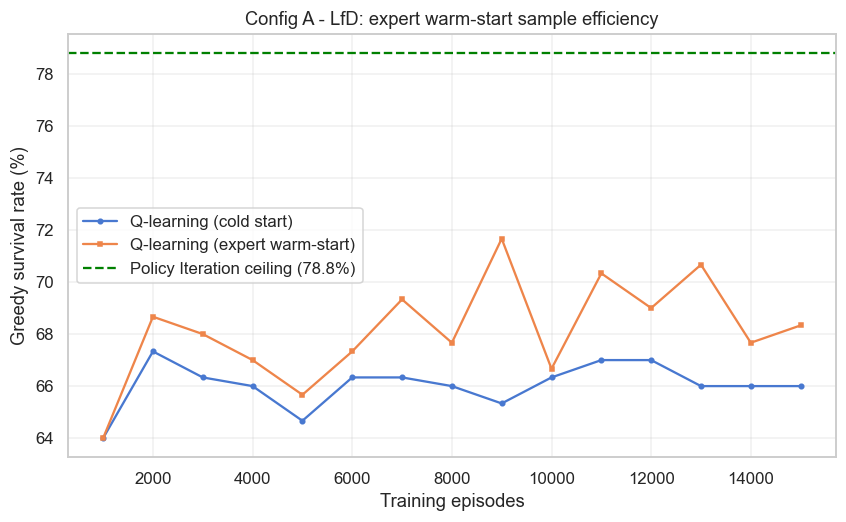

In [91]:
# Creative extension (Config A) - Learning from Demonstrations: expert Q warm-start
from envs.tabular_agents import expert_warmstart_q

# Expert demonstrations -> Q warm-start (DQfD-style pre-training)
Q_init = expert_warmstart_q(n_episodes=3000, gamma=GAMMA, seed=SEED)

cold = QLearning(seed=SEED, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay_steps=15_000)
cold_h = cold.train(n_episodes=15_000, eval_every=1_000, eval_eps=300, verbose=False)
warm = QLearning(seed=SEED, epsilon_start=0.5, epsilon_end=0.01, epsilon_decay_steps=15_000)
warm.Q = Q_init.copy()
warm_h = warm.train(n_episodes=15_000, eval_every=1_000, eval_eps=300, verbose=False)

pi_surv = pi_result['survival_rate'] * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(cold_h['eval_steps'], cold_h['eval_survival']*100, marker='o', ms=3, label='Q-learning (cold start)')
ax.plot(warm_h['eval_steps'], warm_h['eval_survival']*100, marker='s', ms=3, label='Q-learning (expert warm-start)')
ax.axhline(pi_surv, ls='--', color='green', label=f'Policy Iteration ceiling ({pi_surv:.1f}%)')
ax.set_xlabel('Training episodes'); ax.set_ylabel('Greedy survival rate (%)')
ax.set_title('Config A - LfD: expert warm-start sample efficiency')
ax.legend(); ax.grid(alpha=0.3)
plt.savefig(f'{PLOTS_DIR}/configA_warmstart.png', dpi=150, bbox_inches='tight'); plt.show()